# Corpus Analysis of LLM Text

This corpus analysis will revolve around providing quantifiable metrics to the textual data by extracting its stylometry features. These features are commonly divided into different components: lexical (word choice and frequency), syntactic (grammar and sentence structure), semantic (meaning and context of words), structural (text organization), and content-specific (domain) [1,2]. 

Our text dataset have the same domains across all authors due to answering similar questions. This makes content-specific features not effective as a metric for authorship attribution. In addition to this, the structural features are also obsolete as we have prompted the LLMs to follow a specified style and formatting of the text. Aside from this, semantic features are also not effective metrics of authorship attribution, as we want to capture the style of writing rather than the meaning of written texts. With these facts in mind, we decide to focus on lexical and syntactical features. 

## Pre-Processing

In [58]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

### Loading the Dataset

In [59]:
# Load the merged LLM dataset
df = pd.read_csv('llm_data/llm-dataset/eli5_all_llm_answers_cleaned.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Original dataset shape: (5000, 5)
Columns: ['q_id', 'question', 'chatgpt', 'deepseek', 'gemini']


,q_id,question,chatgpt,deepseek,gemini
0,5lchat,Why there was a 'leap second' added to the end...,"Okay, so imagine you have a big clock that hel...",Think of Earth like a spinning top that's slow...,Imagine we have a super-duper perfect clock th...
1,5lcjq6,How do you claim undiscovered land?,Claiming undiscovered land means saying that a...,You can't just go and claim any empty land you...,"Imagine you're exploring a giant playground, a..."
2,5lcl43,Why do we fail to do realistic human CGI (like...,"Okay, so imagine you have a really cool toy th...",We can make amazing CGI animals and monsters b...,Imagine you have a picture of your mommy or da...
3,5lcr1h,Why is it that we calm down when we take a dee...,"When you take a deep breath, it's like giving ...","When you feel scared or upset, your body gets ...",You know how sometimes when you're super excit...
4,5lcsyf,Why does 1080p on a 4k TV look better than 108...,"Okay, imagine you have two different kinds of ...",Imagine your TV screen is made of tiny light s...,Imagine your TV screen is like a giant board m...


### Separating each LLM answer into its own instance

In [60]:
# Separate each LLM answer into its own instance with an author column
instances = []

# Iterate through each row
for idx, row in df.iterrows():
    q_id = row['q_id']
    question = row['question']
    
    # Create an instance for each LLM
    for llm in ['chatgpt', 'deepseek', 'gemini']:
        instances.append({
            'q_id': q_id,
            'question': question,
            'answer': row[llm],
            'author': llm
        })

# Create the new dataframe
df = pd.DataFrame(instances)

print(f"Transformed dataset shape: {df.shape}")

print(f"\nAuthor distribution:")
print(df['author'].value_counts())

Transformed dataset shape: (15000, 4)

Author distribution:
author
chatgpt     5000
deepseek    5000
gemini      5000
Name: count, dtype: int64


## **Lexical Features**
As mentioned before, lexical features pertain to word choice and frequency. These include well-known features such as word frequency, function word frequencies, word n-grams, character n-grams, and vocabulary richness [3]. 

For this study, we will be covering:
- Word Count Distribution
- Word Length Distribution
- Type-Token Ratio
- Function Word Frequencies

Our goal is to find metrics where the LLMs exhibit varying behavior, so that we can have them as candidate features for our models.

#### **Word Count Distribution of LLM Answers**

This metric determines if LLMs have bias towards making long or short answers based on the number of words per answer.

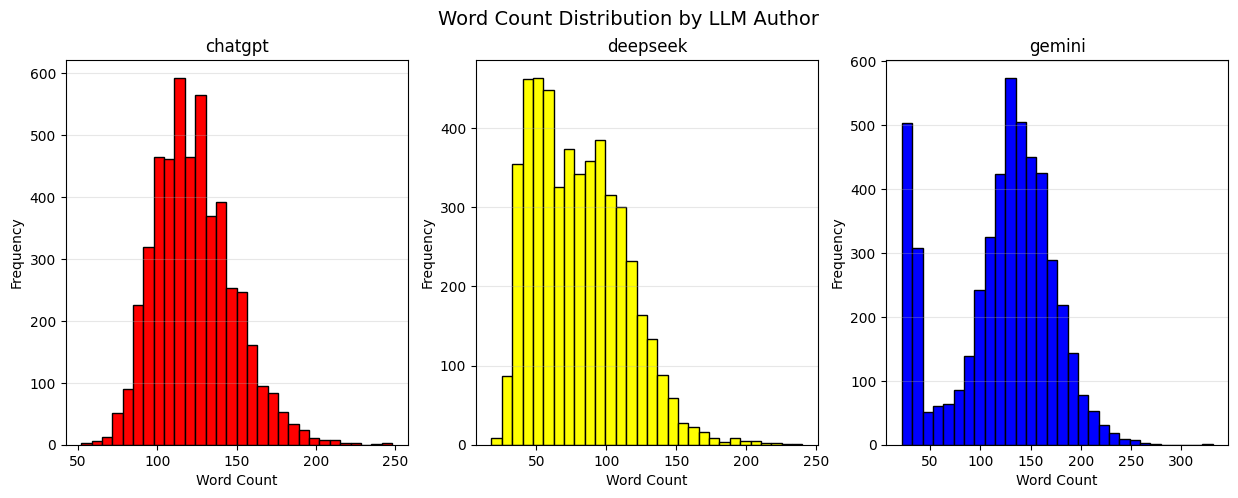

In [61]:
df['word_count'] = df['answer'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
color = ['red', 'yellow', 'blue']

for idx, author in enumerate(authors):
    data = df[df['author'] == author]['word_count']
    axes[idx].hist(data, bins = 30, color = color[idx], edgecolor = 'black')
    axes[idx].set_title(author, fontsize = 12)
    axes[idx].set_xlabel('Word Count', fontsize = 10)
    axes[idx].set_ylabel('Frequency', fontsize = 10)
    axes[idx].grid(axis = 'y', alpha = 0.3)

plt.suptitle('Word Count Distribution by LLM Author', fontsize = 14)
plt.show()

As seen in the histogram, each LLM has a varying distribution for word count. ChatGPT seems to be less skewed than the other LLMs. With this in mind, it can be said that this metric has some potential to be used for classifying.

In [62]:
print("Word Count Statistics by LLM Author:")
print(df.groupby('author')['word_count'].describe())

Word Count Statistics by LLM Author:
           count      mean        std   min    25%    50%    75%    max
author                                                                 
chatgpt   5000.0  123.4090  24.773188  52.0  106.0  121.0  138.0  248.0
deepseek  5000.0   80.0852  32.498757  18.0   52.0   77.0  103.0  240.0
gemini    5000.0  121.2228  51.039696  22.0   97.0  130.0  156.0  331.0


#### **Word Length Distribution of LLM Answers**

This metric determines if LLMs have bias towards using long or short words based on the number of characetrs per word.

In [63]:
# Extract all word lengths for each author
def get_word_lengths(text):
    return [len(word) for word in text.split()]

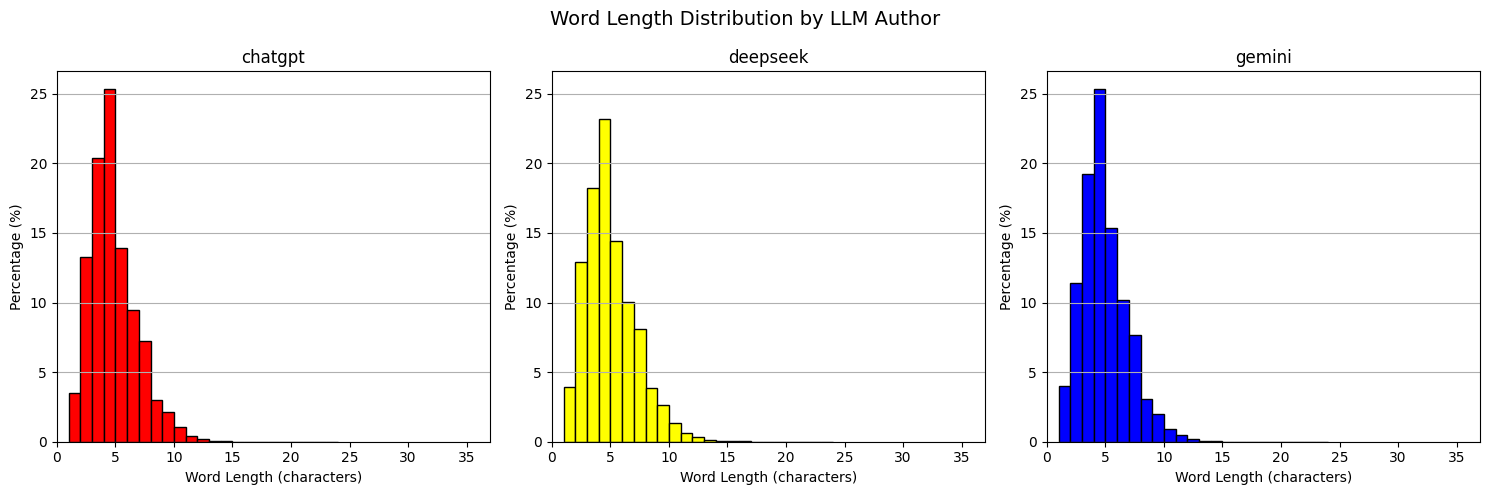

Longest word length for chatgpt: 23 characters
Longest word(s) for chatgpt: “advertiser-unfriendly”
Longest word length for deepseek: 23 characters
Longest word(s) for deepseek: "advertiser-unfriendly"
Longest word length for gemini: 36 characters
Longest word(s) for gemini: "supercalifragilisticexpialidocious"


In [64]:
df['word_lengths'] = df['answer'].apply(get_word_lengths)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
colors = ['red', 'yellow', 'blue']

# Get all word lengths for each author first to determine global max percentage
all_word_lengths = {}
for author in authors:
    word_lengths = []
    for lengths in df[df['author'] == author]['word_lengths']:
        word_lengths.extend(lengths)
    all_word_lengths[author] = word_lengths

# Get max word length across all authors for consistent x-axis
max_word_length = max(max(all_word_lengths[author]) for author in authors)

# Calculate max percentage across all authors for consistent y-axis
max_percentage = 0
for author in authors:
    counts, _ = np.histogram(all_word_lengths[author], bins = range(1, 26))
    percentages = 100 * counts / len(all_word_lengths[author])
    max_percentage = max(max_percentage, percentages.max())



# Plot with consistent axes
for idx, (author, color) in enumerate(zip(authors, colors)):
    axes[idx].hist(all_word_lengths[author], bins=range(1, 25), color = color, edgecolor = 'black', 
                   weights = 100 * np.ones(len(all_word_lengths[author])) / len(all_word_lengths[author]))
    axes[idx].set_title(author, fontsize = 12)
    axes[idx].set_xlabel('Word Length (characters)', fontsize = 10)
    axes[idx].set_ylabel('Percentage (%)', fontsize = 10)
    axes[idx].set_xlim(0, max_word_length + 1)
    axes[idx].set_ylim(0, max_percentage * 1.05)
    axes[idx].grid(axis='y')

plt.suptitle('Word Length Distribution by LLM Author', fontsize = 14)
plt.tight_layout()
plt.show()


#print the longest word for each author
for author in authors:
    longest_word = max(all_word_lengths[author])
    print(f"Longest word length for {author}: {longest_word} characters")
    #print the actual word(s) with that length
    longest_words = set()
    for answer in df[df['author'] == author]['answer']:
        for word in answer.split():
            if len(word) == longest_word:
                longest_words.add(word)
    print(f"Longest word(s) for {author}: {', '.join(longest_words)}")


As seen in the graph, all 3 LLMs follow similar distribution pattern in terms of word length. This means that there is little to no difference in the LLMs' bias towards short or long words. Thus, this metric has no potential to be used for classifying.

### **Type-Token Ratio**

Type-Token Ratio or TTR is a measure of vocabulary richness. It is the number of unique words used divided by the total number of words in the text [4].

In [65]:
def calculate_ttr(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    unique_words = len(set(words))
    total_words = len(words)
    return unique_words / total_words


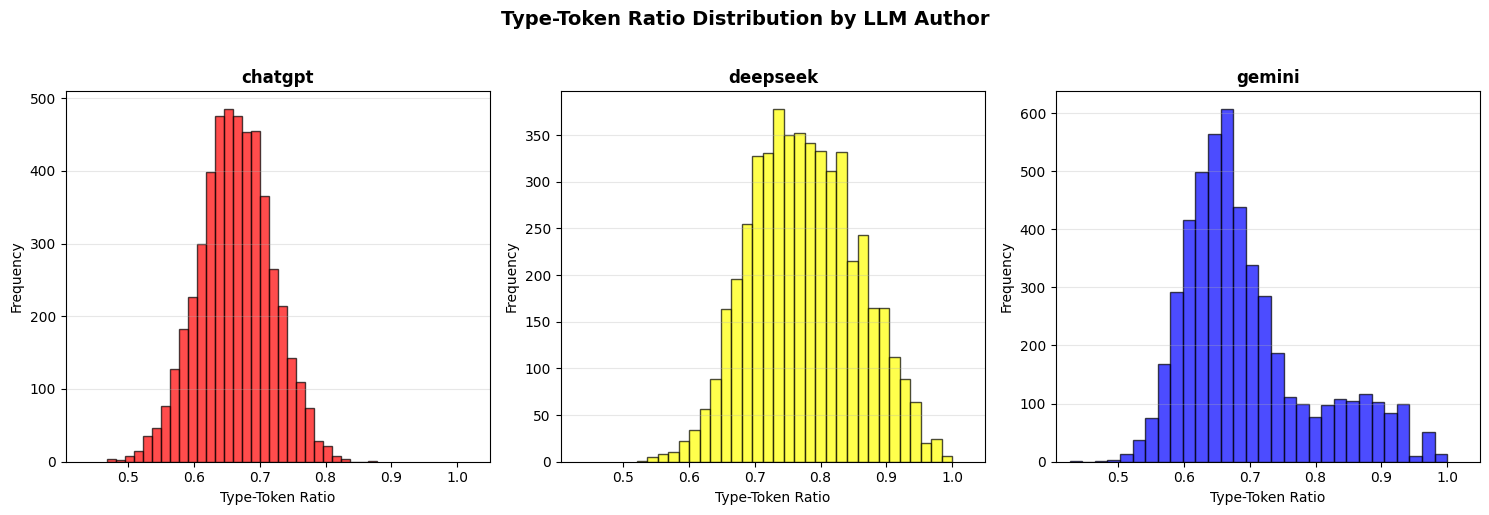


Type-Token Ratio Statistics by LLM Author:
           count      mean       std       min       25%       50%       75%  \
author                                                                         
chatgpt   5000.0  0.662599  0.055395  0.467290  0.625709  0.663366  0.700000   
deepseek  5000.0  0.775773  0.080410  0.520408  0.715909  0.772727  0.833333   
gemini    5000.0  0.694541  0.098756  0.426009  0.626582  0.668750  0.733333   

               max  
author              
chatgpt   0.878788  
deepseek  1.000000  
gemini    1.000000  


In [66]:
df['ttr'] = df['answer'].apply(calculate_ttr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
colors = ['red', 'yellow', 'blue']

# Calculate global min and max for consistent axes
global_min = df['ttr'].min()
global_max = df['ttr'].max()

for idx, (author, color) in enumerate(zip(authors, colors)):
    data = df[df['author'] == author]['ttr']
    axes[idx].hist(data, bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[idx].set_title(author, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Type-Token Ratio', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_xlim(global_min * 0.95, global_max * 1.05)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Type-Token Ratio Distribution by LLM Author', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nType-Token Ratio Statistics by LLM Author:")
print(df.groupby('author')['ttr'].describe())

### **Function Word Frequencies**

Function words are words that have little semantic content of their own and usually indicate a grammatical relationship or generic property. The usage of these words can be considered as a marker of writing style [5].

Here, we get the density of function words in each of the LLM's outputs. We use frequency per 1k words to normalize the data. If we don't, the model would be biased to the one's with the most words, regardless if it is actually common for that LLM itself.

In [67]:
function_words = set(stopwords.words("english"))

# make all text lowercase and tokenize by splitting on non-alphabetic characters
def tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())

rows = []
for _, row in df.iterrows():
    tokens = tokenize(row["answer"])
    total_words = len(tokens)
    if total_words == 0:
        continue
    
    counts = Counter(tokens)
    for w in function_words:
        c = counts.get(w, 0) #if the word is not present, count is 0
        rows.append({
            "author": row["author"],
            "word": w,
            "count": c,
            "freq_per_1k": (c / total_words) * 1000
        })

fw = pd.DataFrame(rows)

In [68]:
# check the first few rows of the function word dataframe
top_n = 20 # for visualization purposes
top_words = (
    fw.groupby("word")["freq_per_1k"]
      .mean()
      .sort_values(ascending=False)
      .head(top_n)
      .index
)

fw_top = fw[fw["word"].isin(top_words)].copy()
print(fw_top.head())

     author  word  count  freq_per_1k
8   chatgpt   the      6    41.379310
10  chatgpt    of      2    13.793103
20  chatgpt    or      1     6.896552
23  chatgpt  your      0     0.000000
31  chatgpt  they      2    13.793103


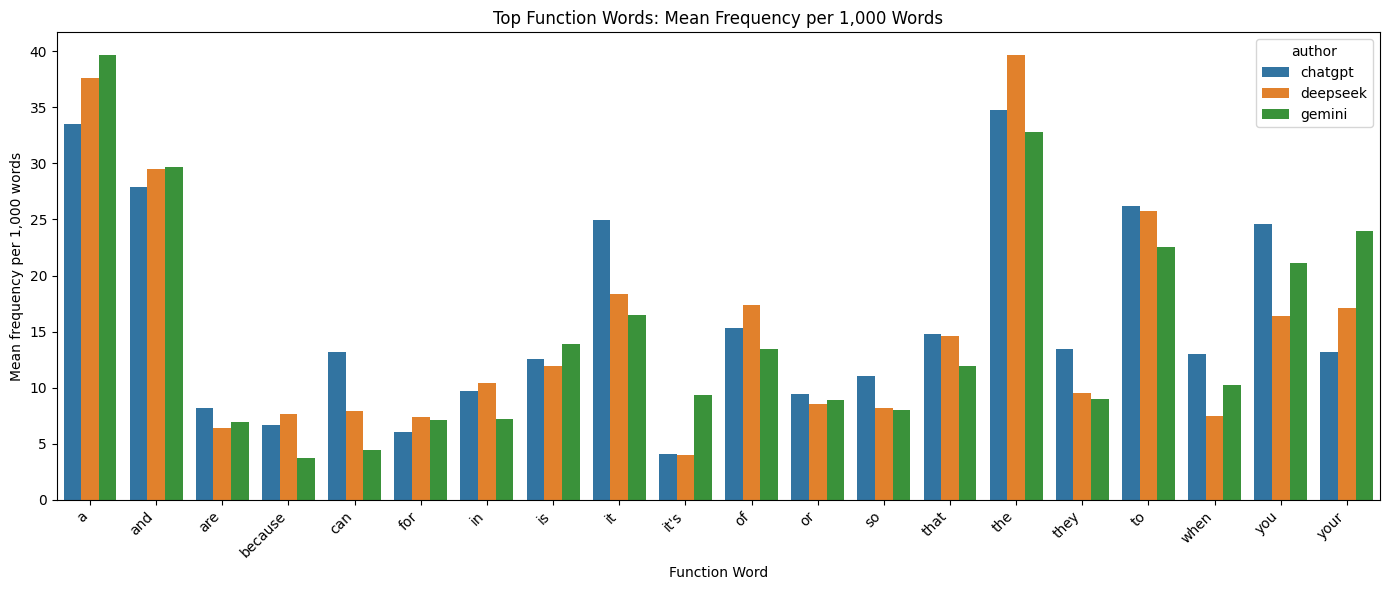

In [69]:
# visualize the top 20 function words by mean frequency per 1,000 words for each author

plt.figure(figsize=(14, 6))
mean_plot = (
    fw_top.groupby(["word", "author"])["freq_per_1k"]
    .mean()
    .reset_index()
)
sns.barplot(data=mean_plot, x="word", y="freq_per_1k", hue="author")
plt.xticks(rotation=45, ha="right")
plt.title("Top Function Words: Mean Frequency per 1,000 Words")
plt.xlabel("Function Word")
plt.ylabel("Mean frequency per 1,000 words")
plt.tight_layout()
plt.show()

From the chart above, we observe that there are words that certain LLMs use more than others. 
* "the" and deepseek
* "it" and chatgpt
* "it's" and gemini

However, there are also word frequencies that don't vary as much.
* "are"

Since we have observed that there are function words that certain authors use more, TF-IDF can help distinguish more patterns and be a better dataset to train machine learning models.

***

## **Term Frequency–Inverse Document Frequency (TF-IDF)**

TF-IDF is a statistical method used in natural language processing and information retrieval to evaluate how important a word is to a document in relation to a larger collection of documents [6].

The formula for TF-IDF is as follows:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

where,
$$\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

$$\text{IDF}(t, D) = \log \left( \frac{\text{Total number of documents } N}{\text{Number of documents containing term } t} \right)$$

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None, 
    lowercase=True,
    ngram_range=(1, 2), 
    min_df=5,             # ignore very rare terms (appear in fewer than 5 documents)
    max_df=1.0,            #  do not ignore very common terms (can help differentiate authors)
    sublinear_tf=True     
)

tf_idf = vectorizer.fit_transform(df["answer"])
terms = vectorizer.get_feature_names_out()
print("TF-IDF shape:", tf_idf.shape)

TF-IDF shape: (15000, 47794)


Justifications:
1. stop_words=none :  we don't want to remove these since it's established that they vary by author
2. min_df=5 : ignore very rare terms (appear in fewer than 5 documents)
3. max_df=1.0 : do not ignore very common terms (can help differentiate authors)
4. sublinear_tf=True : since we don't ignore common terms, this helps very repetitive words from dominating

In [71]:
tfidf_df = pd.DataFrame(tf_idf.toarray(), columns=terms)
tfidf_df["author"] = df["author"].values

author_means = tfidf_df.groupby("author").mean()

top_k = 15 # for visualization purposes
top_terms_by_author = {
    a: author_means.loc[a].sort_values(ascending=False).head(top_k)
    for a in author_means.index
}

for a, s in top_terms_by_author.items():
    print(f"\nTop TF-IDF terms for {a}:")
    print(s.head(5))


Top TF-IDF terms for chatgpt:
the    0.032156
it     0.032076
you    0.031024
and    0.029976
to     0.029831
Name: chatgpt, dtype: float64

Top TF-IDF terms for deepseek:
the     0.034423
and     0.029677
to      0.028216
it      0.025105
like    0.024574
Name: deepseek, dtype: float64

Top TF-IDF terms for gemini:
your     0.032791
super    0.032692
the      0.030335
and      0.029529
you      0.029481
Name: gemini, dtype: float64


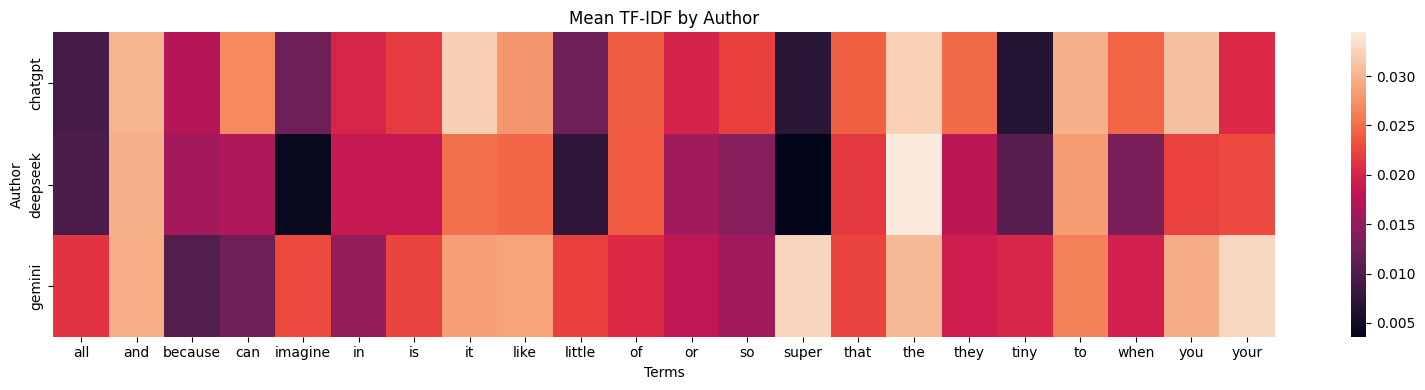

In [72]:
selected_terms = sorted(set().union(*[set(s.index) for s in top_terms_by_author.values()]))
plot_df = author_means[selected_terms]

plt.figure(figsize=(16, 4))
sns.heatmap(plot_df)
plt.title("Mean TF-IDF by Author")
plt.xlabel("Terms")
plt.ylabel("Author")
plt.tight_layout()
plt.show()

***

# **MODEL TRANING**!

### MODEL 1: **Logistic Regression**

Logistic regression is one of the supervised machine learning models used for this task, since this requires multiclass classification (ChatGPT, Gemini, DeepSeek)

In [73]:
# import relevant libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

              precision    recall  f1-score   support

     chatgpt     0.9545    0.9440    0.9492      1000
    deepseek     0.9342    0.9520    0.9430      1000
      gemini     0.9667    0.9590    0.9629      1000

    accuracy                         0.9517      3000
   macro avg     0.9518    0.9517    0.9517      3000
weighted avg     0.9518    0.9517    0.9517      3000



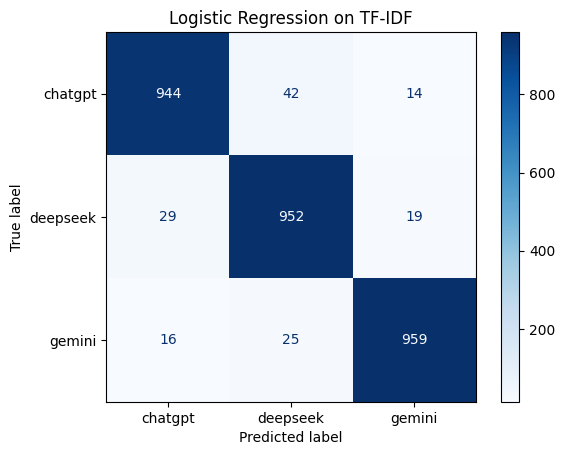

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    tf_idf,
    df["author"],
    test_size=0.2,
    random_state=42,
    stratify=df["author"]
)

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=["chatgpt", "deepseek", "gemini"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression on TF-IDF")
plt.show()

## References

[1] 
Neal, T., Sundararajan, K., Fatima, A., Yan, Y., Xiang, Y., & Woodard, D. (2017). Surveying stylometry techniques and applications. 
    ACM Computing Surveys (CSuR), 50(6), 1-36.

[2]
Huang, B., Chen, C., & Shu, K. (2025). Authorship attribution in the era of llms: Problems, methodologies, and challenges. ACM SIGKDD 
    Explorations Newsletter, 26(2), 21-43.
    
[3]
Stamatatos, E. (2009). A survey of modern authorship attribution methods. Journal of the American Society for information Science and Technology, 
    60(3), 538-556.

[4] 
Sketch Engine. (2024, November 13). Type-token ratio (TTR). https://www.sketchengine.eu/glossary/type-token-ratio-ttr/

[5]
Zhao, Y., & Zobel, J. (2005, October). Effective and scalable authorship attribution using function words. In Asia Information Retrieval Symposium 
    (pp. 174-189). Berlin, Heidelberg: Springer Berlin Heidelberg.

[6]
GeeksforGeeks. (2021, January 20). Understanding TFIDF (Term FrequencyInverse Document Frequency). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/